# 3.9 Aprendizaje por ensamble

El aprendizaje por ensamble combina varios **aprendices débiles** en un **aprendiz fuerte** más robusto y que generaliza mejor. Un ejemplo familiar es el bosque aleatorio, mucho más fuerte que los árboles de decisión individuales que lo componen.

Ventajas clave del aprendizaje por ensamble:
* **Menos sobreajuste**: los métodos de agregación *bootstrap* (*bagging*), como los bosques aleatorios, reducen el riesgo de sobreajuste al combinar las predicciones de varios modelos.
* **Mejor generalización**: los modelos combinados capturan relaciones complejas con más eficacia y generalizan mejor sobre datos diversos.
* **Robustez ante el ruido y los valores atípicos**: agregar las predicciones de muchos modelos diluye la influencia de los puntos de datos individuales ruidosos o atípicos.
* **Mayor estabilidad**: los modelos individuales pueden desempeñarse bien en algunos subconjuntos de los datos y mal en otros; combinar modelos diversos da predicciones más estables entre los subgrupos de los datos.

🖥️ [**Diapositivas — Sesión 17 (vie 6 nov)**](https://geo-smart.github.io/mlgeo-book/slides/2026/lec17_trees_forests_honestly.html)

## Los datos: cuatro clases de eventos sísmicos

Usamos el conjunto de datos curado de eventos sísmicos del [registro 14025693 de Zenodo](https://doi.org/10.5281/zenodo.14025693): 1000 sismos, 1000 explosiones, 1000 eventos superficiales y 1000 ventanas de ruido, registrados en el noroeste del Pacífico de Estados Unidos. Cada evento se describe con características físicas de la forma de onda (duraciones, razones de energía, curtosis, estadísticas espectrales, ...). Las clases están balanceadas, y las características viven en escalas enormemente distintas.

In [1]:
import numpy as np
import pandas as pd
import pooch

In [2]:
SEISMIC_FILES = {
    "1000_earthquakes_physical_features.csv": "md5:28129c8dd1b3e14f655d489577b841b5",
    "1000_explosion_physical_features.csv": "md5:af1342d32e163e961e043364136359b0",
    "1000_noise_physical_features.csv": "md5:16cdb992fed6cf6273d5624f5df905da",
    "1000_surface_physical_features.csv": "md5:9a2c2643030cf058704d68e130654e9d",
}

frames = []
for fname, checksum in SEISMIC_FILES.items():
    path = pooch.retrieve(
        url=f"https://zenodo.org/api/records/14025693/files/{fname}/content",
        known_hash=checksum,
        fname=fname,
        path=pooch.os_cache("mlgeo"),
    )
    frames.append(pd.read_csv(path, index_col=0))
seismic = pd.concat(frames, ignore_index=True)
seismic = seismic.dropna(axis=1)  # drops the one feature column with missing values

In [3]:
X = seismic.drop(columns=["source", "serial_no"])
y = seismic["source"]
print(X.shape)
print(y.value_counts())

(4000, 61)
source
earthquake       1000
explosion        1000
noise            1000
surface event    1000
Name: count, dtype: int64


Usamos la misma división canónica de la lección 3.5, de modo que las exactitudes son directamente comparables entre lecciones: el 25 % de las filas se aparta para la prueba final, con estratificación por clase. Los modelos basados en árboles usan las características crudas; los modelos sensibles a la escala (SVC, k vecinos más cercanos, Bayes ingenuo) reciben un `StandardScaler` dentro de su *pipeline*, ajustado solo sobre los pliegues de entrenamiento.

El modelo de referencia (*baseline*) trivial: con cuatro clases balanceadas, predecir siempre la clase mayoritaria da un 25 % de exactitud. Todo número de aquí en adelante debe leerse contra ese piso.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=2026, stratify=y)

baseline = y_train.value_counts(normalize=True).max()
print(f"Train: {X_train.shape[0]} rows, test: {X_test.shape[0]} rows")
print(f"Majority-class baseline accuracy: {baseline:.2f}")

Train: 3000 rows, test: 1000 rows
Majority-class baseline accuracy: 0.25


```{admonition} La validación cruzada va dentro del conjunto de entrenamiento
:class: warning
La edición anterior de esta lección corría `cross_val_score` sobre el conjunto de datos completo, así que las filas de prueba «apartadas» ayudaban a seleccionar los modelos. La regla: la validación cruzada para comparar y ajustar modelos usa solo `X_train`; el modelo se ajusta después una vez sobre el conjunto de entrenamiento y se reporta una vez sobre `X_test`.
```

## 1. Clasificador por votación

Agregar las predicciones de cada clasificador y predecir la clase que recibe más votos.

![Voting Classifer](votingclassifier.png)
De "Hands on Machine Learning With Sci-kit Learn, Keras, and Tensorflow" (Géron).

Construimos tres modelos base distintos: un Bayes ingenuo (*naive Bayes*) gaussiano, un bosque aleatorio y un clasificador de vectores de soporte. Los modelos de Bayes ingenuo y SVC van envueltos en un *pipeline* con un `StandardScaler`, de modo que el escalado se reajusta en cada pliegue de entrenamiento durante la validación cruzada y nunca ve filas de validación. El bosque aleatorio trabaja sobre las características crudas.

In [5]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

nb_clf = make_pipeline(StandardScaler(), GaussianNB())
rf_clf = RandomForestClassifier(random_state=42)
svc_clf = make_pipeline(StandardScaler(), SVC(random_state=42))

voting_clf = VotingClassifier(
    estimators=[('nb', nb_clf), ('rf', rf_clf), ('svc', svc_clf)],
    voting='hard')

Comparamos el ensamble con sus miembros usando validación cruzada de 5 pliegues — solo sobre el conjunto de entrenamiento.

In [6]:
for name, clf in [('Naive Bayes', nb_clf), ('Random Forest', rf_clf),
                  ('SVC', svc_clf), ('Voting ensemble', voting_clf)]:
    scores = cross_val_score(clf, X_train, y_train, scoring='accuracy', cv=5, n_jobs=-1)
    print(f"{name:16s} CV accuracy: {scores.mean():.3f} +/- {scores.std():.3f}")

Naive Bayes      CV accuracy: 0.784 +/- 0.010


Random Forest    CV accuracy: 0.877 +/- 0.014


SVC              CV accuracy: 0.880 +/- 0.012


Voting ensemble  CV accuracy: 0.875 +/- 0.011


Ahora ajustamos el ensamble por votación sobre el conjunto de entrenamiento completo y reportamos su exactitud de prueba — una sola vez.

In [7]:
voting_clf.fit(X_train, y_train)
voting_test = accuracy_score(y_test, voting_clf.predict(X_test))
print(f"Voting classifier test accuracy: {voting_test:.3f}")

Voting classifier test accuracy: 0.874


Note que tomar el promedio de la probabilidad predicha, en lugar de su máximo, también es una posibilidad. Solo pueden evaluarse los clasificadores que producen probabilidades, cosa que la SVM no hace por defecto. Fije ``voting`` en ``soft`` para comparar con la probabilidad media.

## 2. *Bagging* y *pasting*

Este enfoque usa el mismo algoritmo de modelo, pero remuestrea el conjunto de entrenamiento. Para el remuestreo **con reemplazo** (*bootstrap*) se llama agregación *bootstrap* (*bagging*); para el remuestreo **sin reemplazo**, se llama *pasting*.

Se entrenan varios modelos sobre datos distintos y luego se agregan las predicciones (la *moda estadística* para la clasificación y el *promedio* para la regresión). El modelo agregado tiende a tener menor varianza que los modelos individuales, parecido a lo que obtendría un solo modelo si se entrenara con más datos.

Abajo hacemos *bagging* con 50 clasificadores de k vecinos más cercanos, cada uno entrenado sobre una mitad aleatoria de las filas de entrenamiento. El modelo de *bagging* va dentro de un *pipeline* con escalador porque kNN es sensible a la escala. Cambie ``n_estimators``, ``max_samples`` o ``bootstrap`` y observe el score validado de forma cruzada.

In [8]:
from sklearn.ensemble import BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier

bag_clf = make_pipeline(
    StandardScaler(),
    BaggingClassifier(
        estimator=KNeighborsClassifier(),
        n_estimators=50,     # number of models to train
        max_samples=0.5,     # each model sees half of the training rows
        bootstrap=True,      # True: bagging; False: pasting
        n_jobs=-1,           # use all available CPU cores
    ))
scores = cross_val_score(bag_clf, X_train, y_train, cv=5)
print(f"Bagged kNN CV accuracy: {scores.mean():.3f}")

Bagged kNN CV accuracy: 0.839


### Evaluación *out-of-bag*

El muestreo con reemplazo tiene un efecto secundario útil. Cuando se extraen $m$ muestras con reemplazo de $m$ filas de entrenamiento, cada *bootstrap* contiene solo cerca del 63 % de las filas únicas; el otro ~37 % nunca entra en el conjunto de entrenamiento de ese modelo. Esas filas excluidas forman un conjunto de validación gratuito para ese modelo. Fije ``oob_score=True`` y el `BaggingClassifier` puntuará cada fila de entrenamiento usando solo los modelos que nunca la vieron.

In [9]:
from sklearn.tree import DecisionTreeClassifier

oob_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=200,
    oob_score=True,
    random_state=42,
)
oob_clf.fit(X_train, y_train)
oob_test = accuracy_score(y_test, oob_clf.predict(X_test))
print(f"Out-of-bag score: {oob_clf.oob_score_:.3f}")
print(f"Test accuracy:    {oob_test:.3f}")

Out-of-bag score: 0.875
Test accuracy:    0.889


Los dos números están cerca, y así debería ser: el score *out-of-bag* es una estimación honesta, porque cada predicción proviene de modelos que nunca entrenaron con esa fila — la misma propiedad que tiene un conjunto de prueba apartado.

### La dispersión del ensamble como incertidumbre

Los 200 árboles del *bagging* dan más que una etiqueta de clase. Cada árbol emite un voto, y el reparto de los votos es en sí mismo una medición: cuando 195 de 200 árboles coinciden, el ensamble está confiado; cuando los votos se dispersan entre tres clases, el ensamble le está diciendo que no sabe. El modelo de *bagging* ajustado guarda sus árboles en `estimators_`, así que podemos contar los votos nosotros mismos y adjuntar una confianza a cada predicción de prueba, sin reentrenar.


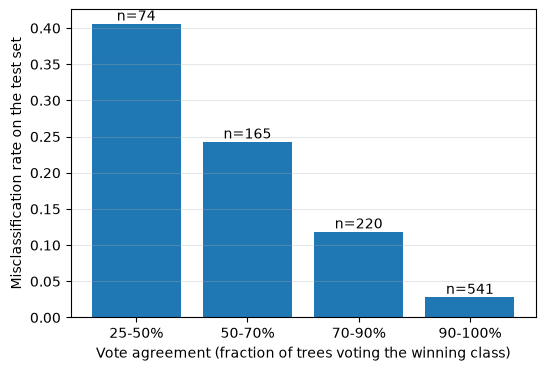

In [10]:
import matplotlib.pyplot as plt

# per-tree predictions on the test set: one row per tree
tree_votes = np.stack([tree.predict(X_test.to_numpy())
                       for tree in oob_clf.estimators_])

# each tree predicts a class index; count the votes for each class
n_classes = len(oob_clf.classes_)
vote_frac = np.stack([(tree_votes == k).mean(axis=0)
                      for k in range(n_classes)], axis=1)
agreement = vote_frac.max(axis=1)  # fraction voting the winning class
errors = oob_clf.predict(X_test) != y_test.to_numpy()

edges = [0.25, 0.5, 0.7, 0.9, 1.001]
bin_labels = ['25-50%', '50-70%', '70-90%', '90-100%']
bin_idx = np.digitize(agreement, edges) - 1
error_rate = [errors[bin_idx == b].mean() for b in range(4)]
counts = [int((bin_idx == b).sum()) for b in range(4)]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(bin_labels, error_rate)
for i, (e, n) in enumerate(zip(error_rate, counts)):
    ax.text(i, e + 0.005, f"n={n}", ha='center')
ax.set_xlabel('Vote agreement (fraction of trees voting the winning class)')
ax.set_ylabel('Misclassification rate on the test set')
ax.grid(alpha=0.3, axis='y')
plt.show()


Los árboles que coinciden suelen tener razón: por encima del 90 % de acuerdo, el ensamble se equivoca cerca del 3 % de las veces, mientras que las muestras que dividen el bosque por debajo del 50 % de acuerdo están equivocadas cerca del 40 % de las veces. El ensamble ordena sus propias predicciones por confiabilidad antes de que se revele etiqueta alguna; en un catálogo operativo, los eventos de bajo acuerdo son los que se envían a un analista.

```{admonition} Incertidumbre epistémica frente a aleatoria
:class: note
El desacuerdo entre árboles entrenados sobre distintas muestras *bootstrap* estima la incertidumbre **epistémica**: la incertidumbre por lo que el modelo no ha aprendido, que se encoge a medida que crecen los datos de entrenamiento. No captura la incertidumbre **aleatoria**: la aleatoriedad de la propia medición, como el ruido del sensor, que ninguna cantidad de datos de entrenamiento elimina. Ambos términos están definidos en el [glosario](../reference/glossary.md).
```

La misma receta — entrenar muchos modelos, leer su desacuerdo como incertidumbre — regresa en la lección 4.5 como ensambles profundos de redes neuronales.


## 3. Potenciación (*boosting*)

La idea detrás de los métodos de *boosting* es entrenar predictores en secuencia, cada uno tratando de corregir a su predecesor.

### 3.1 AdaBoost

El algoritmo AdaBoost entrena un predictor nuevo prestando más atención (dando más peso) a las malas predicciones del predictor anterior. Por ejemplo, en una clasificación, un primer predictor subajustará los datos y clasificará mal algunas etiquetas. El segundo predictor pondera con más fuerza los datos que fueron mal clasificados. El parámetro ``learning_rate`` fija la magnitud de esa reponderación.

AdaBoost funciona con cualquier clasificador que produzca probabilidades de clase (p. ej., árboles de decisión, kNN; busque clasificadores con un método ``predict_proba()``). Aquí los aprendices débiles son árboles poco profundos (profundidad 2), que es la elección estándar.

```{admonition} Nota de API
:class: tip
El código antiguo pasaba ``algorithm='SAMME.R'`` a `AdaBoostClassifier`. La variante SAMME.R fue eliminada de scikit-learn; no pase un argumento ``algorithm``.
```

In [11]:
from sklearn.ensemble import AdaBoostClassifier

ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2),
    n_estimators=200,
    learning_rate=0.5,
    random_state=42,
)
ada_clf.fit(X_train, y_train)
ada_test = accuracy_score(y_test, ada_clf.predict(X_test))
print(f"AdaBoost test accuracy: {ada_test:.3f}")

AdaBoost test accuracy: 0.874


### 3.2 *Gradient boosting*

El *gradient boosting* (potenciación de gradiente) también construye árboles en secuencia, pero cada árbol nuevo ajusta los residuos del ensamble actual:
- Se entrena un solo árbol pequeño sobre los datos (un *aprendiz débil*).
- Un segundo árbol pequeño se entrena sobre los residuos entre los datos y las predicciones del primer árbol. Los residuos se hacen más pequeños.
- Un tercer árbol pequeño ajusta los residuos restantes, y así sucesivamente.
- La predicción final es la suma de las predicciones de todos los árboles.

``n_estimators`` limita el número total de árboles; demasiados árboles sobreajustan. El ``learning_rate`` escala la contribución de cada árbol; una tasa menor necesita más árboles.

El *gradient boosting* ganó el aprendizaje automático tabular. Las implementaciones basadas en histogramas — LightGBM, XGBoost y el `HistGradientBoostingClassifier` de scikit-learn — discretizan las características en contenedores (*bins*) para hacer crecer los árboles rápido, y en 2026 son la elección por defecto para tablas de características como esta. Los bosques aleatorios siguen siendo un modelo de referencia fuerte, robusto y casi sin ajuste. Los árboles dividen sobre umbrales de las características, así que ninguno de estos modelos necesita entradas escaladas.

Primero, el potenciador de gradiente por histogramas incluido en scikit-learn:

In [12]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_clf = HistGradientBoostingClassifier(random_state=42)
hgb_clf.fit(X_train, y_train)
hgb_test = accuracy_score(y_test, hgb_clf.predict(X_test))
print(f"HistGradientBoosting test accuracy: {hgb_test:.3f}")

HistGradientBoosting test accuracy: 0.898


Luego LightGBM, una biblioteca independiente de uso extendido con la misma interfaz de scikit-learn:

In [13]:
from lightgbm import LGBMClassifier

lgbm_clf = LGBMClassifier(random_state=42, verbose=-1)
lgbm_clf.fit(X_train, y_train)
lgbm_test = accuracy_score(y_test, lgbm_clf.predict(X_test))
print(f"LightGBM test accuracy: {lgbm_test:.3f}")

LightGBM test accuracy: 0.892


## 4. Apilamiento (*stacking*)

La votación trata a todos los modelos base por igual. El apilamiento (*stacking*) entrena, en cambio, un **meta-aprendiz** sobre las predicciones de los modelos base: aprende a qué modelo creerle, y dónde. Los modelos base producen predicciones; el meta-aprendiz (a menudo una regresión logística simple) toma esas predicciones como características de entrada y las ajusta a las etiquetas verdaderas.

Aquí hay una trampa de fuga de datos: si el meta-aprendiz se entrenara con predicciones de los modelos base sobre filas que esos modelos ya vieron, aprendería a confiar en predicciones sobreajustadas. El `StackingClassifier` de scikit-learn lo evita generando las predicciones base con validación cruzada interna, de modo que el meta-aprendiz solo ve las predicciones de cada modelo base sobre filas con las que ese modelo no entrenó.

Apilamos tres bases diversas — un bosque aleatorio, un potenciador de gradiente por histogramas y un kNN escalado — con una regresión logística encima.

In [14]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

base_estimators = [
    ('rf', RandomForestClassifier(random_state=42)),
    ('hgb', HistGradientBoostingClassifier(random_state=42)),
    ('knn', make_pipeline(StandardScaler(), KNeighborsClassifier())),
]

stack_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1,
)
stack_clf.fit(X_train, y_train)
stack_test = accuracy_score(y_test, stack_clf.predict(X_test))
print(f"Stacking test accuracy: {stack_test:.3f}")

Stacking test accuracy: 0.899


Para comparar, un ensamble de votación dura con las mismas tres bases sobre la misma división:

In [15]:
voting3_clf = VotingClassifier(estimators=base_estimators, voting='hard', n_jobs=-1)
voting3_clf.fit(X_train, y_train)
voting3_test = accuracy_score(y_test, voting3_clf.predict(X_test))
print(f"Voting (same bases) test accuracy: {voting3_test:.3f}")

Voting (same bases) test accuracy: 0.891


## Resumen

La exactitud de prueba y la exhaustividad (*recall*) por clase de cada ensamble de esta lección, contra el modelo de referencia trivial. La exactitud agregada esconde las fallas específicas de cada clase; las columnas de exhaustividad muestran, para cada clase verdadera, la fracción de sus eventos que el modelo atrapa.


In [16]:
from sklearn.metrics import recall_score

fitted = {
    'Voting (NB + RF + SVC)': voting_clf,
    'Bagged trees (OOB demo)': oob_clf,
    'AdaBoost': ada_clf,
    'HistGradientBoosting': hgb_clf,
    'LightGBM': lgbm_clf,
    'Stacking (RF + HGB + kNN)': stack_clf,
    'Voting (RF + HGB + kNN)': voting3_clf,
}
classes = sorted(y.unique())
rows = {'Majority-class baseline': [baseline] + [np.nan] * len(classes)}
for name, clf in fitted.items():
    pred = clf.predict(X_test)
    rows[name] = ([accuracy_score(y_test, pred)]
                  + list(recall_score(y_test, pred,
                                      average=None, labels=classes)))
results = pd.DataFrame(
    rows, index=['test accuracy'] + [f'recall: {c}' for c in classes]).T
results.round(3)


,test accuracy,recall: earthquake,recall: explosion,recall: noise,recall: surface event
Majority-class baseline,0.250,NaN,NaN,NaN,NaN
Voting (NB + RF + SVC),0.874,0.884,0.768,0.932,0.912
Bagged trees (OOB demo),0.889,0.868,0.824,0.940,0.924
AdaBoost,0.874,0.868,0.804,0.920,0.904
HistGradientBoosting,0.898,0.888,0.836,0.932,0.936
LightGBM,0.892,0.880,0.828,0.928,0.932
Stacking (RF + HGB + kNN),0.899,0.880,0.844,0.932,0.940
Voting (RF + HGB + kNN),0.891,0.884,0.804,0.944,0.932


Todos los ensambles superan el piso del 25 % por un margen amplio, y las diferencias entre los ensambles fuertes son pequeñas en este conjunto de datos. Las columnas de exhaustividad muestran dónde viven los errores restantes: todos los modelos atrapan el ruido y los eventos superficiales con una exhaustividad del 90 % o mejor, mientras que la exhaustividad sobre las explosiones queda entre 0.77 y 0.84 para todos — la exactitud agregada esconde una clase que se clasifica mal de dos a tres veces más a menudo que las demás. El hábito que hay que conservar: compare los modelos por validación cruzada dentro del conjunto de entrenamiento, gaste el conjunto de prueba exactamente una vez y reporte la exhaustividad por clase junto al score agregado.
